# CREDIT RISK DATASET

## 1. Importar librerías y *Credit Risk Dataset*

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import json

# Preprocesamiento y partición de datos
from sklearn.model_selection import train_test_split, cross_val_score, cross_validate, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Modelos de clasificación
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import (
    BaggingClassifier,
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
    VotingClassifier,
    StackingClassifier
)

# Pipeline, preprocesamiento y búsqueda de hiperparámetros
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import KNNImputer
from sklearn.model_selection import GridSearchCV

# Métricas de evaluación
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    roc_curve,
    roc_auc_score,
    make_scorer,
)

# Visualización LaTeX en notebook
from IPython.display import display, Math

import time

In [2]:
df = pd.read_csv(r"C:\Users\usuario\OneDrive\Proyectos\TFG\credit_risk_dataset.csv")

## 2. Análisis exploratorio

In [3]:
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [4]:
df.tail()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
32576,57,53000,MORTGAGE,1.0,PERSONAL,C,5800,13.16,0,0.11,N,30
32577,54,120000,MORTGAGE,4.0,PERSONAL,A,17625,7.49,0,0.15,N,19
32578,65,76000,RENT,3.0,HOMEIMPROVEMENT,B,35000,10.99,1,0.46,N,28
32579,56,150000,MORTGAGE,5.0,PERSONAL,B,15000,11.48,0,0.10,N,26
32580,66,42000,RENT,2.0,MEDICAL,B,6475,9.99,0,0.15,N,30


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [6]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [7]:
df.isnull().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

In [8]:
df.nunique()

person_age                      58
person_income                 4295
person_home_ownership            4
person_emp_length               36
loan_intent                      6
loan_grade                       7
loan_amnt                      753
loan_int_rate                  348
loan_status                      2
loan_percent_income             77
cb_person_default_on_file        2
cb_person_cred_hist_length      29
dtype: int64

In [9]:
# Eliminar registros con person_age > 90 y person_emp_length == 123
print(f"Registros antes: {len(df)}")
df = df[df['person_age'] <= 90]
df = df[df['person_emp_length'] != 123]
print(f"Registros después: {len(df)}")

Registros antes: 32581
Registros después: 32573


## 3. Configuración del experimento

Se fijan en esta sección los tres elementos comunes a **todos** los experimentos del notebook: la partición de datos, los *pipelines* de preprocesamiento y el esquema de validación cruzada con las métricas de evaluación.

- **Partición train/test** (sección 3.1): 80 % / 20 %, estratificada por `loan_status` y `random_state=42`.
- **Pipelines de preprocesamiento** (sección 3.2): tres `ColumnTransformer` —uno por familia de algoritmos— que aplican `KNNImputer` (k = 5) para imputar los valores faltantes en `person_emp_length` e `loan_int_rate`, `StandardScaler` sobre las variables numéricas donde corresponde, y `OneHotEncoder` con distinta política de referencia según el modelo.
- **Esquema de validación cruzada y métricas** (sección 3.3): `StratifiedKFold` de 5 *folds* y siete métricas evaluadas simultáneamente en cada `GridSearchCV` (AUC, exactitud, tasa de error, precisión, sensibilidad, especificidad y F1-Score).

Estos tres componentes se reutilizan sin modificación en los modelos base (sección 4) y en todos los esquemas de ensamblado de las secciones 5–8 (*bagging* y *Random Forest*, *AdaBoost* y *Gradient Boosting*, *voting* y *stacking*).

### 3.1. División train/test

In [10]:
# Separar features y target
X = df.drop(columns=['loan_status'])
y = df['loan_status']

# División train/test (80/20, estratificada)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape[0]} registros ({y_train.mean()*100:.2f}% default)")
print(f"Test:  {X_test.shape[0]} registros ({y_test.mean()*100:.2f}% default)")

Train: 26058 registros (21.82% default)
Test:  6515 registros (21.81% default)


### 3.2. Pipelines de preprocesamiento

Se definen **tres** `ColumnTransformer`, uno por familia de algoritmos, para aplicar el preprocesado más adecuado a cada tipo de modelo. Estos mismos preprocesadores se reutilizan en todos los esquemas de ensamblado de las secciones 5–8.

| Preprocesador | Imputación | Escalado | OneHot `drop` | Modelos que lo usan |
|---|---|---|---|---|
| `preprocessor_lr` | KNNImputer(k=5) | **StandardScaler** | `'first'` | Regresión Logística |
| `preprocessor_knn` | KNNImputer(k=5) | **StandardScaler** | `None` | K-NN |
| `preprocessor_dt` | KNNImputer(k=5) | — | `None` | Árbol |

In [11]:
# Columnas numéricas y categóricas
num_cols = ['person_age', 'person_income', 'person_emp_length',
            'loan_amnt', 'loan_int_rate', 'loan_percent_income',
            'cb_person_cred_hist_length']

cat_cols = ['person_home_ownership', 'loan_intent', 'loan_grade',
            'cb_person_default_on_file']

# Pipelines numéricos
num_pipeline_scaled = Pipeline([
    ('imputer', KNNImputer(n_neighbors=5)),
    ('scaler', StandardScaler())
])
num_pipeline_unscaled = Pipeline([
    ('imputer', KNNImputer(n_neighbors=5))
])

# Pipelines categóricos 
cat_pipeline_lr = Pipeline([
    ('encoder', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
])
cat_pipeline_knn = Pipeline([
    ('encoder', OneHotEncoder(drop=None, handle_unknown='ignore', sparse_output=False))
])
cat_pipeline_dt = Pipeline([
    ('encoder', OneHotEncoder(drop=None, handle_unknown='ignore', sparse_output=False))
])

# ColumnTransformers por modelo
preprocessor_lr = ColumnTransformer([
    ('num', num_pipeline_scaled, num_cols),
    ('cat', cat_pipeline_lr, cat_cols)
])
preprocessor_knn = ColumnTransformer([
    ('num', num_pipeline_scaled, num_cols),
    ('cat', cat_pipeline_knn, cat_cols)
])
preprocessor_dt = ColumnTransformer([
    ('num', num_pipeline_unscaled, num_cols),
    ('cat', cat_pipeline_dt, cat_cols)
])

### 3.3. Esquema de validación cruzada y métricas

In [12]:
# Especificidad 
def specificity_score(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return tn / (tn + fp)

# Tasa de error
def error_rate_score(y_true, y_pred):
    return 1 - accuracy_score(y_true, y_pred)

# Diccionario de métricas
scoring = {
    'AUC':           'roc_auc',
    'Exactitud':     'accuracy',
    'Tasa de error': make_scorer(error_rate_score),
    'Precisión':     'precision',
    'Sensibilidad':  'recall',
    'Especificidad': make_scorer(specificity_score),
    'F1-Score':      'f1'
}

# Estrategia de CV: 5 folds estratificados
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

## 4. Modelos de clasificación base

Se entrenan tres clasificadores base —**Regresión Logística**, **k-NN** y **Árbol de Clasificación**— empleando la partición, los preprocesadores y el esquema de validación definidos en la sección 3. Para cada modelo se realiza una búsqueda de hiperparámetros con `GridSearchCV` (`refit='AUC'`), se reportan las métricas medias en 5-fold CV de la mejor combinación y se reentrena el estimador ganador sobre todo `X_train`.

### 4.1. Regresión Logística

Se entrena una regresión logística **sin penalización** (`C=np.inf`). No hay hiperparámetros que ajustar por validación cruzada: simplemente se estiman los coeficientes con el solver 'lbfgs' y se reportan las métricas medias en 5-fold CV.

In [ ]:
# Regresión Logística 
lr_pipe = Pipeline([
    ('preprocessor', preprocessor_lr),
    ('classifier', LogisticRegression(C=np.inf, max_iter=2000, random_state=42))
])

# Hiperparámetros fijos 
lr_best_params = {'penalty': None, 'solver': 'lbfgs', 'max_iter': 2000}

# Validación cruzada (5 folds) con todas las métricas
lr_cv = cross_validate(lr_pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
lr_metrics = {m: lr_cv[f'test_{m}'].mean() for m in scoring}

print("=== Regresión Logística ===")
print(f"Hiperparámetros: {lr_best_params}")
print("\nMétricas medias (5-fold CV):")
for m, v in lr_metrics.items():
    print(f"  {m:<14}: {v:.4f}")

# Reentrenar sobre todo el conjunto de entrenamiento
lr_pipe.fit(X_train, y_train)
print("\n→ Modelo reentrenado sobre todo X_train.")

# Guardar hiperparámetros en JSON (estructura común: best_params + cv_metrics)
lr_best_json = {
    'best_params': lr_best_params,
    'cv_metrics': {m: round(float(v), 4) for m, v in lr_metrics.items()}
}
with open('lr_best_params.json', 'w') as f:
    json.dump(lr_best_json, f, indent=4)
print("→ Hiperparámetros guardados en lr_best_params.json")

In [122]:
# Definición lr_model, coefs e intercept para Odds Ratios
lr_prep = lr_pipe.named_steps['preprocessor']
ohe_lr  = lr_prep.named_transformers_['cat'].named_steps['encoder']
cat_feature_names_lr = list(ohe_lr.get_feature_names_out(cat_cols))
feature_names = num_cols + cat_feature_names_lr

lr_model  = lr_pipe.named_steps['classifier']
coefs     = lr_model.coef_[0]
intercept = lr_model.intercept_[0]

In [123]:
# Tabla de los Odds Ratios
or_df = pd.DataFrame({
    'Variable':         feature_names,
    'Coeficiente (b)':  np.round(coefs, 4),
    'Odds Ratio (e^b)': np.round(np.exp(coefs), 4)
}).sort_values('Odds Ratio (e^b)', ascending=False).reset_index(drop=True)
or_df.index += 1

print(f'Intercepto (b₀): {intercept:.4f}\n')
or_df

Intercepto (b₀): -2.2694



,Variable,Coeficiente (b),Odds Ratio (e^b)
1,loan_grade_G,6.3114,550.8068
2,loan_grade_F,3.1679,23.7571
3,loan_grade_E,2.7244,15.2467
4,loan_grade_D,2.5062,12.2578
5,loan_percent_income,1.4755,4.3734
6,person_home_ownership_RENT,0.8373,2.3101
7,loan_grade_C,0.4087,1.5048
8,person_home_ownership_OTHER,0.2750,1.3165
9,loan_int_rate,0.2110,1.2350
10,loan_grade_B,0.1990,1.2202


### 4.2. K-NN

Búsqueda de la mejor combinación de hiperparámetros entre las 48 posibles:
- `n_neighbors` ∈ {5, 11, 21, 25, 29, 32, 35, 37, 71, 151, 251, 401}
- `weights` ∈ {'uniform', 'distance'}
- `metric` ∈ {'euclidean', 'manhattan'}

In [ ]:
# K-NN
knn_pipe = Pipeline([
    ('preprocessor', preprocessor_knn),
    ('classifier', KNeighborsClassifier())
])

# Se prueba con 48 combinaciones de hiperparámetros (12 × 2 × 2)
knn_params = {
    'classifier__n_neighbors': [5, 11, 21, 25, 29, 32, 35, 37, 71, 151, 251, 401],
    'classifier__weights': ['uniform', 'distance'],
    'classifier__metric': ['euclidean', 'manhattan']
}

knn_grid = GridSearchCV(
    knn_pipe, knn_params,
    cv=cv, scoring=scoring, refit='AUC',
    n_jobs=12, verbose=2
)
knn_grid.fit(X_train, y_train)

# Mejor combinación y métricas asociadas (medias de los 5 folds)
knn_best_idx = knn_grid.best_index_
knn_best_params = {k.replace('classifier__', ''): v for k, v in knn_grid.best_params_.items()}
knn_metrics = {m: knn_grid.cv_results_[f'mean_test_{m}'][knn_best_idx] for m in scoring}

print("=== K-NN ===")
print(f"Mejores hiperparámetros: {knn_best_params}")
print("\nMétricas medias (5-fold CV) con la mejor combinación:")
for m, v in knn_metrics.items():
    print(f"  {m:<14}: {v:.4f}")

print("\n→ Modelo reentrenado sobre todo X_train (refit='AUC').")

# Guardar hiperparámetros en JSON (estructura común: best_params + cv_metrics)
knn_best_json = {
    'best_params': knn_best_params,
    'cv_metrics': {m: round(float(v), 4) for m, v in knn_metrics.items()}
}
with open('knn_best_params.json', 'w') as f:
    json.dump(knn_best_json, f, indent=4)
print("→ Hiperparámetros guardados en knn_best_params.json")

Fitting 5 folds for each of 48 candidates, totalling 240 fits
=== K-NN ===
Mejores hiperparámetros: {'metric': 'manhattan', 'n_neighbors': 37, 'weights': 'distance'}

Métricas medias (5-fold CV) con la mejor combinación:
  AUC           : 0.9003
  Exactitud     : 0.8962
  Tasa de error : 0.1038
  Precisión     : 0.9207
  Sensibilidad  : 0.5733
  Especificidad : 0.9863
  F1-Score      : 0.7066

→ Modelo reentrenado sobre todo X_train (refit='AUC').
→ Hiperparámetros guardados en knn_best_params.json


#### Curva AUC frente a $k$

Fijada la mejor combinación de hiperparámetros (`weights='distance'`, `metric='manhattan'`), se representa el AUC medio en validación cruzada en función del número de vecinos $k$. Esta curva permite visualizar empíricamente el **dilema sesgo-varianza** discutido en la Sección 2.4: valores muy pequeños de $k$ generan modelos de alta varianza (sobreajustan al ruido del *train*), mientras que valores muy grandes incrementan el sesgo (suavizan en exceso la frontera de decisión). El óptimo se sitúa en el valor de $k$ que minimiza el error en CV.

Curva AUC vs k  (weights='distance', metric='manhattan')

  k  mean_test_AUC
  5         0.8723
 11         0.8891
 21         0.8976
 25         0.8984
 29         0.8991
 32         0.9000
 35         0.9002
 37         0.9003
 71         0.8992
151         0.8957
251         0.8931
401         0.8892


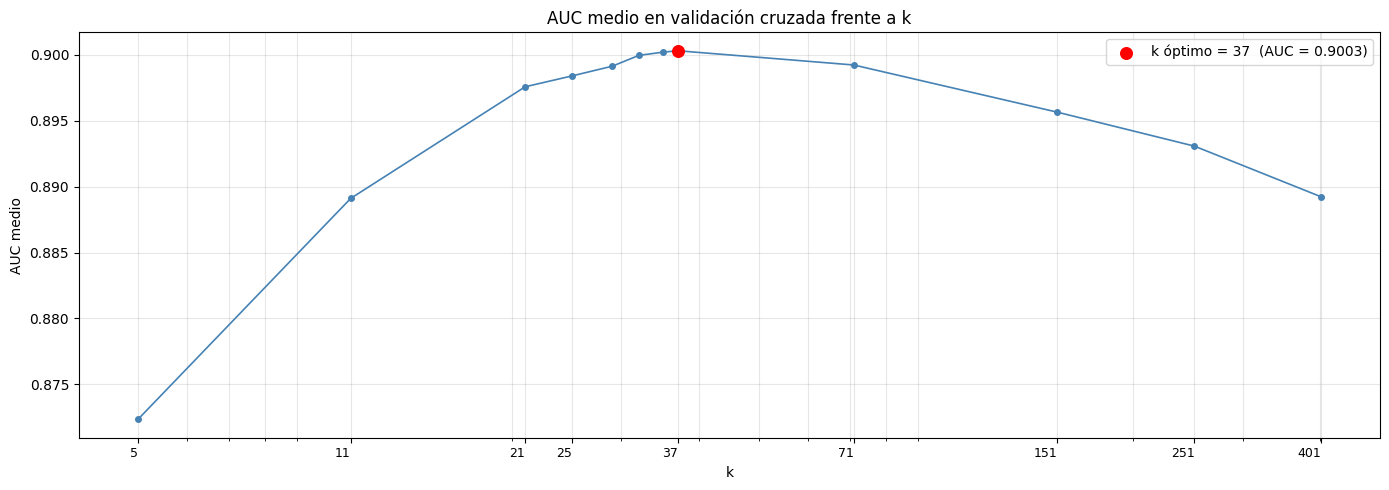

In [48]:
# Curva AUC vs k con la mejor combinación de weights y metric
best_w = knn_best_params['weights']
best_m = knn_best_params['metric']

knn_cv_df = pd.DataFrame(knn_grid.cv_results_)
mask = (
    (knn_cv_df['param_classifier__weights'] == best_w) &
    (knn_cv_df['param_classifier__metric']  == best_m)
)
curve_df = (
    knn_cv_df.loc[mask]
        .assign(k=lambda d: d['param_classifier__n_neighbors'].astype(int))
        [['k', 'mean_test_AUC']]
        .sort_values('k')
        .reset_index(drop=True)
)

print(f"Curva AUC vs k  (weights='{best_w}', metric='{best_m}')\n")
print(curve_df.round(4).to_string(index=False))

# Gráfico
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(curve_df['k'], curve_df['mean_test_AUC'],
        'o-', color='steelblue', markersize=4, linewidth=1.2)

best_k   = knn_best_params['n_neighbors']
best_auc = curve_df.loc[curve_df['k'] == best_k, 'mean_test_AUC'].values[0]
ax.scatter([best_k], [best_auc], color='red', zorder=5, s=70,
           label=f'k óptimo = {best_k}  (AUC = {best_auc:.4f})')

ax.set_xscale('log')

# Ticks equiespaciados en escala logarítmica (~12), snapping al k real más cercano
tick_targets = np.geomspace(curve_df['k'].min(), curve_df['k'].max(), 12)
tick_vals = [curve_df['k'].iloc[(curve_df['k'] - t).abs().argmin()] for t in tick_targets]
tick_vals = sorted(set(tick_vals))
ax.set_xticks(tick_vals)
ax.set_xticklabels(tick_vals, ha='right', fontsize=9)

ax.set_xlabel('k')
ax.set_ylabel('AUC medio')
ax.set_title('AUC medio en validación cruzada frente a k')
ax.grid(True, alpha=0.3, which='both')
ax.legend()
plt.tight_layout()
plt.savefig('Fotos/k-NN - AUC vs k.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.3. Árbol de Clasificación

Búsqueda de la mejor combinación de hiperparámetros entre las 448 posibles:
- `criterion` ∈ {'gini', 'entropy'}
- `max_depth` ∈ {3, 5, 7, 10, 15, 20, None}
- `min_samples_split` ∈ {2, 5, 10, 20}
- `min_samples_leaf` ∈ {1, 5, 10, 20}
- `classifier__class_weight` ∈ {None, 'balanced'}

In [ ]:
# Árbol de Clasificación 
dt_pipe = Pipeline([
    ('preprocessor', preprocessor_dt),
    ('classifier', DecisionTreeClassifier(random_state=42))
])

# Se prueba con 448 combinaciones de hiperparámetros
dt_params = {
    'classifier__criterion': ['gini', 'entropy'],
    'classifier__class_weight': [None, 'balanced'],
    'classifier__max_depth': [3, 5, 7, 10, 15, 20, None],
    'classifier__min_samples_split': [2, 5, 10, 20],
    'classifier__min_samples_leaf': [1, 5, 10, 20]
}

dt_grid = GridSearchCV(
    dt_pipe, dt_params,
    cv=cv, scoring=scoring, refit='AUC',
    n_jobs=12, verbose=2
)
dt_grid.fit(X_train, y_train)

# Mejor combinación y métricas asociadas (medias de los 5 folds)
dt_best_idx = dt_grid.best_index_
dt_best_params = {k.replace('classifier__', ''): v for k, v in dt_grid.best_params_.items()}
dt_metrics = {m: dt_grid.cv_results_[f'mean_test_{m}'][dt_best_idx] for m in scoring}

print("=== Árbol de Clasificación ===")
print(f"Mejores hiperparámetros: {dt_best_params}")
print("\nMétricas medias (5-fold CV) con la mejor combinación:")
for m, v in dt_metrics.items():
    print(f"  {m:<14}: {v:.4f}")

print("\n→ Modelo reentrenado sobre todo X_train (refit='AUC').")

# Guardar hiperparámetros en JSON (estructura común: best_params + cv_metrics)
dt_best_json = {
    'best_params': dt_best_params,
    'cv_metrics': {m: round(float(v), 4) for m, v in dt_metrics.items()}
}
with open('dt_best_params.json', 'w') as f:
    json.dump(dt_best_json, f, indent=4)
print("→ Hiperparámetros guardados en dt_best_params.json")

#### Visualización del árbol de clasificación

Se representa el árbol entrenado limitado a profundidad $2$ para que sea legible. 

In [25]:
# Pipeline reentrenado y nombres de las variables predictoras tras el preprocesado
dt_pipe_fit = dt_grid.best_estimator_
dt_model    = dt_pipe_fit.named_steps['classifier']
dt_prep     = dt_pipe_fit.named_steps['preprocessor']

ohe_dt            = dt_prep.named_transformers_['cat'].named_steps['encoder']
cat_feature_names = list(ohe_dt.get_feature_names_out(cat_cols))
feature_names_dt  = num_cols + cat_feature_names

# Gráfico del árbol limitado a profundidad 2
fig, ax = plt.subplots(figsize=(18, 9))
artists = plot_tree(
    dt_model,
    feature_names=feature_names_dt,
    class_names=['No Default', 'Default'],
    filled=True, rounded=True, fontsize=11,
    max_depth=2, ax=ax
)

# Recorrido DFS en preorden hasta profundidad 2 (mismo orden que dibuja plot_tree)
tree_ = dt_model.tree_
orden = []
def _dfs(n, d, max_d=2):
    orden.append(n)
    if d >= max_d or tree_.children_left[n] == tree_.children_right[n]:
        return
    _dfs(tree_.children_left[n],  d + 1, max_d)
    _dfs(tree_.children_right[n], d + 1, max_d)
_dfs(0, 0)

# Recoloreado: verde si la clase mayoritaria es Y=0 (No Default), rojo si es Y=1 (Default),
# con intensidad proporcional a la pureza del nodo.
real_artists = [a for a in artists if 'samples' in a.get_text()]

for ann, n in zip(real_artists, orden):
    valores     = tree_.value[n][0]
    clase_mayor = int(valores.argmax())
    pureza      = valores.max() / valores.sum()
    intensidad  = 0.2 + (pureza - 0.5)

    cmap  = plt.cm.Reds if clase_mayor == 1 else plt.cm.Greens
    color = cmap(intensidad)

    ann.set_bbox(dict(boxstyle='round,pad=0.3',
                      facecolor=color, edgecolor='gray', linewidth=0.5))

ax.set_title(
    f'Árbol de Clasificación  —  profundidad real: {dt_model.get_depth()}, '
    f'nodos hoja: {dt_model.get_n_leaves()}  (visualización limitada a profundidad 2)',
    fontsize=14
)
plt.tight_layout()
plt.savefig('Fotos/arbol_clasificacion.png', dpi=150, bbox_inches='tight')
plt.show()

NameError: name 'dt_grid' is not defined

#### Importancia de las variables predictoras

A partir del árbol se cuantifica la importancia que se asigna a cada variable predictora siguiendo los siguientes cuatro pasos:

**1. Reducción ponderada de impureza de un nodo.** Para cada nodo interno $t$ con hijos izquierdo $t_L$ y derecho $t_R$, se mide cuánto mejora la pureza global del árbol gracias a esa partición:

$$\Delta i(t) = \dfrac{N_t}{N}\left[\,i(t) - \dfrac{N_{t_L}}{N_t}\,i(t_L) - \dfrac{N_{t_R}}{N_t}\,i(t_R)\right]$$

donde $i(\cdot)$ es la impureza (Gini o entropía según el criterio elegido), $N$ es el número total de muestras de entrenamiento y $N_t$, $N_{t_L}$, $N_{t_R}$ son las muestras que caen en cada nodo.

**2. Importancia por variable.** Para cada variable predictora $X_j$, su importancia bruta se obtiene sumando las reducciones de impureza de todos los nodos internos que parten por $X_j$:

$$\widetilde{\mathrm{Imp}}(X_j) = \sum_{\substack{t \in \mathcal{T}_{\text{int}} \\ v(t) = X_j}} \Delta i(t)$$

donde $\mathcal{T}_{\text{int}}$ es el conjunto de nodos internos y $v(t)$ la variable por la que se parte en el nodo $t$. Las variables que no participan en ninguna partición tienen importancia bruta $0$.

**3. Importancia normalizada por variable.** Las importancias brutas se normalizan dividiendo por su suma para que formen una distribución (sumen $1$):

$$\mathrm{Imp}(X_j) = \dfrac{\widetilde{\mathrm{Imp}}(X_j)}{\sum_{k=1}^{p} \widetilde{\mathrm{Imp}}(X_k)}$$

Esta cantidad es precisamente el atributo `feature_importances_` que devuelve `scikit-learn`.

**4. Importancia por variable original.** Como las variables categóricas se han codificado mediante *one-hot encoding* en varias *dummies*, la importancia del paso anterior se calcula sobre las variables ya codificadas. Para una lectura más interpretable, se suman las contribuciones de todas las *dummies* de una misma variable categórica:

$$\mathrm{Imp}(X) = \sum_{c \in \mathcal{C}(X)} \mathrm{Imp}(X_c)$$

donde $\mathcal{C}(X)$ es el conjunto de categorías de $X$.

In [ ]:
# Importancia de cada variable predictora codificada
imp_df = pd.DataFrame({
    'Variable':    feature_names_dt,
    'Importancia': dt_model.feature_importances_.round(4)
}).sort_values('Importancia', ascending=False).reset_index(drop=True)
imp_df.index += 1

# Agregación por variable original (suma de las dummies de cada categórica)
def variable_origen(nombre):
    for c in cat_cols:
        if nombre.startswith(c + '_'):
            return c
    return nombre

imp_agg = (
    imp_df.assign(**{'Variable original': imp_df['Variable'].map(variable_origen)})
          .groupby('Variable original', as_index=False)['Importancia'].sum()
          .sort_values('Importancia', ascending=False)
          .reset_index(drop=True)
)
imp_agg.index += 1
imp_agg['Importancia'] = imp_agg['Importancia'].round(4)

# Gráficos
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

imp_df.plot.barh(x='Variable', y='Importancia', ax=axes[0],
                 legend=False, color='steelblue')
axes[0].invert_yaxis()
axes[0].set_title('Importancia por variable codificada')
axes[0].set_xlabel('Importancia'); axes[0].set_ylabel('')

imp_agg.plot.barh(x='Variable original', y='Importancia', ax=axes[1],
                  legend=False, color='darkorange')
axes[1].invert_yaxis()
axes[1].set_title('Importancia por variable original')
axes[1].set_xlabel('Importancia'); axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('Fotos/importancia_variables_dt.png', dpi=150, bbox_inches='tight')
plt.show()

imp_df  # Tabla con la importancia por variable codificada

### 4.4. Resumen comparativo

In [ ]:
# Tabla comparativa con las métricas medias en 5-fold CV
summary = pd.DataFrame({
    'Regresión Logística':   lr_metrics,
    'K-NN':                  knn_metrics,
    'Árbol de Clasificación': dt_metrics
}).T.round(4)

summary

,AUC,Exactitud,Tasa de error,Precisión,Sensibilidad,Especificidad,F1-Score
Regresión Logística,0.8711,0.8666,0.1334,0.7649,0.5612,0.9518,0.6474
K-NN,0.8997,0.8977,0.1023,0.9196,0.5821,0.9858,0.7129
Árbol de Clasificación,0.9168,0.8918,0.1082,0.7442,0.7687,0.9262,0.7562


## 5. Bagging y Random Forest

### 5.1. Bagging con k-NN como estimador base

El objetivo de esta subsección es doble: 
1. Ilustrar cómo el *bagging* reduce el error de forma más pronunciada cuando el estimador base tiene **alta varianza** (k pequeño, el k-NN sobreajusta), y cómo esta ganancia se diluye conforme el modelo base se estabiliza (k grande, baja varianza).
2. Ver si algún bagging con k-NN como modelo base supera al k-NN óptimo de la sección 4.

Se fijan `weights='distance'` y `metric='manhattan'` en sus valores óptimos y se combinan **12 combinaciones** de hiperparámetros: `n_neighbors` ∈ {5, 11, 21, 25, 29, 32, 35, 37, 71, 151, 251, 401}

In [35]:
k_values = [5, 11, 21, 25, 29, 32, 35, 37, 71, 151, 251, 401]

bagging_knn_records = []

t0 = time.perf_counter()
for k in k_values:
    pipe = Pipeline([
        ('preprocessor', preprocessor_knn),
        ('classifier', BaggingClassifier(
            estimator=KNeighborsClassifier(
                n_neighbors=k, weights='distance', metric='manhattan'
            ),
            n_estimators=50,
            bootstrap=True,
            max_samples=1.0,
            random_state=42,
            n_jobs=-1                # paraleliza los 200 estimadores
        ))
    ])

    cv_out = cross_validate(
        pipe, X_train, y_train,
        cv=cv, scoring=scoring, n_jobs=1   # ya paralelizado dentro de Bagging
    )

    record = {'n_estimators': 50, 'n_neighbors': k,
              **{m: float(np.mean(cv_out[f'test_{m}'])) for m in scoring}}
    bagging_knn_records.append(record)
    print(f"  k = {k:>4}   AUC = {record['AUC']:.6f}")
t1 = time.perf_counter()

bagging_knn_results = pd.DataFrame(bagging_knn_records)

# Mejor combinación según AUC medio
best_idx = bagging_knn_results['AUC'].idxmax()
bagging_knn_best_params_val = {
    'n_estimators': int(bagging_knn_results.loc[best_idx, 'n_estimators']),
    'n_neighbors':  int(bagging_knn_results.loc[best_idx, 'n_neighbors'])
}
bagging_knn_metrics = {m: float(bagging_knn_results.loc[best_idx, m]) for m in scoring}

print("\n=== Bagging k-NN ===")
print(f"Mejores hiperparámetros: {bagging_knn_best_params_val}")
print(f"→ Tiempo total: {t1 - t0:.1f} s")
print("\nMétricas medias (5-fold CV) con la mejor combinación:")
for m, v in bagging_knn_metrics.items():
    print(f"  {m:<14}: {v:.6f}")

print("\nRendimiento de todas las combinaciones:")
print(bagging_knn_results.round(6).to_string(index=False))

# Guardar JSON
with open('bagging_knn_best_params.json', 'w') as f:
    json.dump({'best_params': bagging_knn_best_params_val,
               'cv_metrics':  {m: round(v, 6) for m, v in bagging_knn_metrics.items()}},
              f, indent=4)

with open('bagging_knn_all_results.json', 'w') as f:
    json.dump(bagging_knn_results.round(6).to_dict(orient='records'), f, indent=4)

print("\n→ Resultados guardados en bagging_knn_best_params.json y bagging_knn_all_results.json")

  k =    5   AUC = 0.885681
  k =   11   AUC = 0.894454
  k =   21   AUC = 0.899174
  k =   25   AUC = 0.899890
  k =   29   AUC = 0.900243
  k =   32   AUC = 0.900389
  k =   35   AUC = 0.900448
  k =   37   AUC = 0.900361
  k =   71   AUC = 0.899230
  k =  151   AUC = 0.895757
  k =  251   AUC = 0.892967
  k =  401   AUC = 0.889086

=== Bagging k-NN ===
Mejores hiperparámetros: {'n_estimators': 50, 'n_neighbors': 35}
→ Tiempo total: 1512.4 s

Métricas medias (5-fold CV) con la mejor combinación:
  AUC           : 0.900448
  Exactitud     : 0.896424
  Tasa de error : 0.103576
  Precisión     : 0.920955
  Sensibilidad  : 0.574569
  Especificidad : 0.986256
  F1-Score      : 0.707604

Rendimiento de todas las combinaciones:
 n_estimators  n_neighbors      AUC  Exactitud  Tasa de error  Precisión  Sensibilidad  Especificidad  F1-Score
           50            5 0.885681   0.897114       0.102886   0.865684      0.625571       0.972904  0.726266
           50           11 0.894454   0.901

#### Curva AUC frente a k

La gráfica siguiente de AUC frente a k muestra empíricamente cómo el beneficio del ensamblado decrece con k, en línea con la predicción de Breiman de que el *bagging* solo es útil cuando el estimador base es inestable.

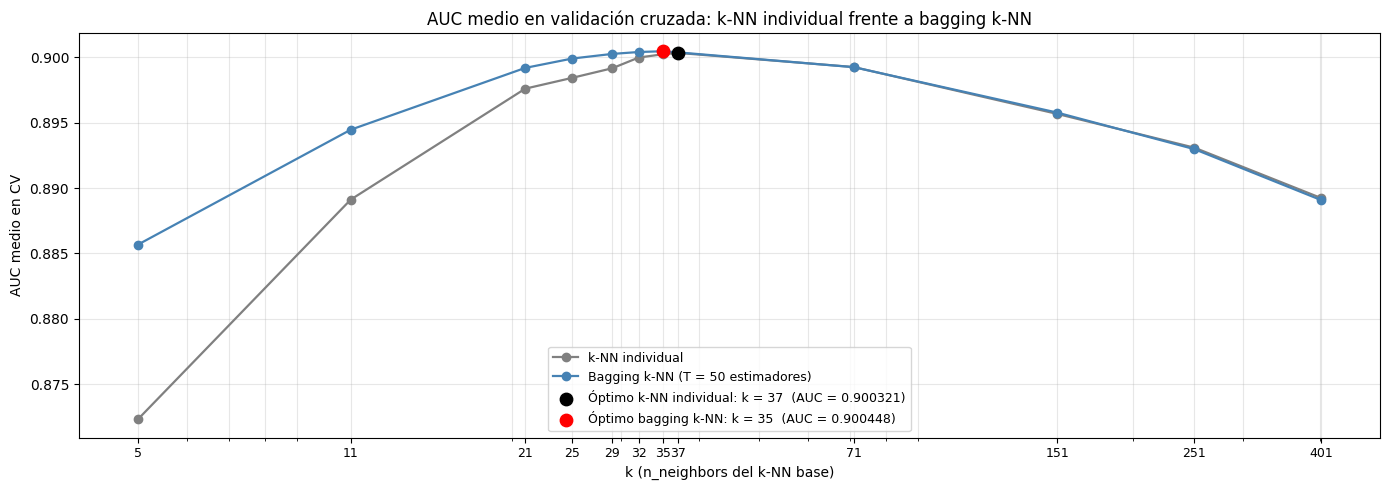

: 

In [ ]:
# Cargar referencia del k-NN sin bagging si no está en memoria
if 'knn_metrics' not in globals() or 'knn_best_params' not in globals():
    with open('knn_best_params.json', 'r') as f:
        _knn_json = json.load(f)
    knn_best_params = _knn_json['best_params']
    knn_metrics     = _knn_json['cv_metrics']

# Curva AUC del k-NN individual sobre los mismos 12 valores de k
best_w = knn_best_params['weights']
best_m = knn_best_params['metric']

knn_cv_df = pd.DataFrame(knn_grid.cv_results_)
mask = (
    (knn_cv_df['param_classifier__weights'] == best_w) &
    (knn_cv_df['param_classifier__metric']  == best_m)
)
knn_curve = (
    knn_cv_df.loc[mask]
        .assign(n_neighbors=lambda d: d['param_classifier__n_neighbors'].astype(int))
        [['n_neighbors', 'mean_test_AUC']]
        .rename(columns={'mean_test_AUC': 'AUC'})
        .sort_values('n_neighbors')
        .reset_index(drop=True)
)

# Curva AUC del bagging k-NN
bag_curve = bagging_knn_results.sort_values('n_neighbors').reset_index(drop=True)

# Gráfico
fig, ax = plt.subplots(figsize=(14, 5))

# k-NN individual
ax.plot(knn_curve['n_neighbors'], knn_curve['AUC'],
        'o-', color='gray', markersize=6, linewidth=1.6,
        label='k-NN individual')

# Bagging k-NN
ax.plot(bag_curve['n_neighbors'], bag_curve['AUC'],
        'o-', color='steelblue', markersize=6, linewidth=1.6,
        label='Bagging k-NN (T = 50 estimadores)')

# Óptimo k-NN individual
best_k_knn   = knn_best_params['n_neighbors']
best_auc_knn = knn_curve.loc[knn_curve['n_neighbors'] == best_k_knn, 'AUC'].values[0]
ax.scatter([best_k_knn], [best_auc_knn], color='black', zorder=6, s=80,
           label=f'Óptimo k-NN individual: k = {best_k_knn}  (AUC = {best_auc_knn:.6f})')

# Óptimo bagging k-NN
best_k_bag   = bagging_knn_best_params_val['n_neighbors']
best_auc_bag = bagging_knn_metrics['AUC']
ax.scatter([best_k_bag], [best_auc_bag], color='red', zorder=6, s=80,
           label=f'Óptimo bagging k-NN: k = {best_k_bag}  (AUC = {best_auc_bag:.6f})')

ax.set_xscale('log')
ax.set_xticks(k_values)
ax.set_xticklabels(k_values, fontsize=9)
ax.set_xlabel('k (n_neighbors del k-NN base)')
ax.set_ylabel('AUC medio en CV')
ax.set_title('AUC medio en validación cruzada: k-NN individual frente a bagging k-NN')
ax.grid(True, alpha=0.3, which='both')
ax.legend(fontsize=9, loc='lower center')
plt.tight_layout()
plt.savefig('Fotos/bagging_knn_vs_knn_AUC_vs_k.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.2. Bagging con árbol de clasificación como estimador base

Se van compara *bagging* con árboles de decisión en su versión original (con `bootstrap=TRUE`) y en una versión alternativa con `bootstrap=FALSE` para ilustrar como este bootstrap mejora la capacidad predictiva del modelo al hacer que varíe el conjunto de entrenamiento. 

In [37]:
# Bagging con árbol de clasificación sin podar como estimador base
bagging_tree_pipe = Pipeline([
    ('preprocessor', preprocessor_dt),
    ('classifier', BaggingClassifier(
        estimator=DecisionTreeClassifier(
            max_depth=None,
            min_samples_leaf=1,
            min_samples_split=2,
            class_weight='balanced',
            random_state=42
        ),
        random_state=42
    ))
])

bagging_tree_params = {
    'classifier__n_estimators': [500],
    'classifier__bootstrap':    [True, False],
}

t0 = time.perf_counter()
bagging_tree_grid = GridSearchCV(
    bagging_tree_pipe, bagging_tree_params,
    cv=cv, scoring=scoring, refit='AUC',
    n_jobs=-1, verbose=2
)
bagging_tree_grid.fit(X_train, y_train)
t1 = time.perf_counter()

# Mejor combinación global
bt_cv_df = pd.DataFrame(bagging_tree_grid.cv_results_)
bagging_tree_best_idx = bagging_tree_grid.best_index_
bagging_tree_best_params_val = {k.replace('classifier__', ''): v
                                 for k, v in bagging_tree_grid.best_params_.items()}
bagging_tree_metrics = {m: float(bt_cv_df.loc[bagging_tree_best_idx, f'mean_test_{m}'])
                        for m in scoring}

print("=== Bagging Árbol de Clasificación ===")
print(f"Mejores hiperparámetros (global): {bagging_tree_best_params_val}")
print(f"\n→ Tiempo de entrenamiento (GridSearchCV): {t1 - t0:.1f} s")
print("\nMétricas medias (5-fold CV) — mejor configuración global:")
for m, v in bagging_tree_metrics.items():
    print(f"  {m:<14}: {v:.4f}")

# Mejor configuración con bootstrap=True
mask_bt = bt_cv_df['param_classifier__bootstrap'] == True
bt_idx = bt_cv_df.loc[mask_bt, 'mean_test_AUC'].idxmax()
bagging_tree_bootstrap_params_val = {
    'n_estimators': int(bt_cv_df.loc[bt_idx, 'param_classifier__n_estimators']),
    'bootstrap':    True
}
bagging_tree_bootstrap_metrics = {m: float(bt_cv_df.loc[bt_idx, f'mean_test_{m}']) for m in scoring}

print("\nMétricas medias (5-fold CV) — mejor configuración bootstrap=True:")
for m, v in bagging_tree_bootstrap_metrics.items():
    print(f"  {m:<14}: {v:.4f}")

# Mejor configuración con bootstrap=False (pasting)
mask_pt = bt_cv_df['param_classifier__bootstrap'] == False
pt_idx = bt_cv_df.loc[mask_pt, 'mean_test_AUC'].idxmax()
bagging_tree_pasting_params_val = {
    'n_estimators': int(bt_cv_df.loc[pt_idx, 'param_classifier__n_estimators']),
    'bootstrap':    False
}
bagging_tree_pasting_metrics = {m: float(bt_cv_df.loc[pt_idx, f'mean_test_{m}']) for m in scoring}

print("\nMétricas medias (5-fold CV) — mejor configuración bootstrap=False (pasting):")
for m, v in bagging_tree_pasting_metrics.items():
    print(f"  {m:<14}: {v:.4f}")

print("\n→ Modelo reentrenado sobre todo X_train (refit='AUC').")

# Guardar JSONs (estructura común: best_params + cv_metrics)
json_saves = [
    ('bagging_tree_best_params.json',          bagging_tree_best_params_val,       bagging_tree_metrics),
    ('bagging_tree_bootstrap_best_params.json', bagging_tree_bootstrap_params_val, bagging_tree_bootstrap_metrics),
    ('bagging_tree_pasting_best_params.json',   bagging_tree_pasting_params_val,   bagging_tree_pasting_metrics),
]
for fname, params, metrics in json_saves:
    data = {
        'best_params': params,
        'cv_metrics':  {m: round(v, 4) for m, v in metrics.items()}
    }
    with open(fname, 'w') as f:
        json.dump(data, f, indent=4)
print("→ JSONs guardados: bagging_tree_best_params.json, bagging_tree_bootstrap_best_params.json, bagging_tree_pasting_best_params.json")

Fitting 5 folds for each of 2 candidates, totalling 10 fits
=== Bagging Árbol de Clasificación ===
Mejores hiperparámetros (global): {'bootstrap': True, 'n_estimators': 500}

→ Tiempo de entrenamiento (GridSearchCV): 113.7 s

Métricas medias (5-fold CV) — mejor configuración global:
  AUC           : 0.9369
  Exactitud     : 0.9325
  Tasa de error : 0.0675
  Precisión     : 0.9661
  Sensibilidad  : 0.7160
  Especificidad : 0.9930
  F1-Score      : 0.8224

Métricas medias (5-fold CV) — mejor configuración bootstrap=True:
  AUC           : 0.9369
  Exactitud     : 0.9325
  Tasa de error : 0.0675
  Precisión     : 0.9661
  Sensibilidad  : 0.7160
  Especificidad : 0.9930
  F1-Score      : 0.8224

Métricas medias (5-fold CV) — mejor configuración bootstrap=False (pasting):
  AUC           : 0.8561
  Exactitud     : 0.8911
  Tasa de error : 0.1089
  Precisión     : 0.7480
  Sensibilidad  : 0.7555
  Especificidad : 0.9290
  F1-Score      : 0.7518

→ Modelo reentrenado sobre todo X_train (refi

### 5.3. Random Forest

Se lleva a cabo `GridSearchCV` con  `max_features` ∈ {`'log2'`, `'sqrt'`, 0.3, 0.5, 0.7}.

In [40]:
# Random Forest
rf_pipe = Pipeline([
    ('preprocessor', preprocessor_dt),
    ('classifier', RandomForestClassifier(
        max_depth=None,
        min_samples_leaf=1,
        min_samples_split=2,
        bootstrap=True,
        class_weight='balanced',
        random_state=42
    ))
])

rf_params = {
    'classifier__n_estimators': [500],
    'classifier__max_features': ['log2', 'sqrt', 0.3, 0.5, 0.7, 1]
}

t0 = time.perf_counter()
rf_grid = GridSearchCV(
    rf_pipe, rf_params,
    cv=cv, scoring=scoring, refit='AUC',
    n_jobs=-1, verbose=2
)
rf_grid.fit(X_train, y_train)
t1 = time.perf_counter()

rf_best_idx = rf_grid.best_index_
rf_best_params_val = {k.replace('classifier__', ''): v for k, v in rf_grid.best_params_.items()}
rf_metrics = {m: float(rf_grid.cv_results_[f'mean_test_{m}'][rf_best_idx]) for m in scoring}

print("=== Random Forest ===")
print(f"Mejores hiperparámetros: {rf_best_params_val}")
print(f"\n→ Tiempo de entrenamiento (GridSearchCV): {t1 - t0:.1f} s")
print("\nMétricas medias (5-fold CV) con la mejor combinación:")
for m, v in rf_metrics.items():
    print(f"  {m:<14}: {v:.4f}")
print("\n→ Modelo reentrenado sobre todo X_train (refit='AUC').")

# Guardar hiperparámetros en JSON (estructura común: best_params + cv_metrics)
rf_best_json = {
    'best_params': rf_best_params_val,
    'cv_metrics':  {m: round(v, 4) for m, v in rf_metrics.items()}
}
with open('rf_best_params.json', 'w') as f:
    json.dump(rf_best_json, f, indent=4)
print("→ Hiperparámetros guardados en rf_best_params.json")

Fitting 5 folds for each of 6 candidates, totalling 30 fits
=== Random Forest ===
Mejores hiperparámetros: {'max_features': 0.7, 'n_estimators': 500}

→ Tiempo de entrenamiento (GridSearchCV): 99.9 s

Métricas medias (5-fold CV) con la mejor combinación:
  AUC           : 0.9384
  Exactitud     : 0.9336
  Tasa de error : 0.0664
  Precisión     : 0.9727
  Sensibilidad  : 0.7160
  Especificidad : 0.9944
  F1-Score      : 0.8248

→ Modelo reentrenado sobre todo X_train (refit='AUC').
→ Hiperparámetros guardados en rf_best_params.json


### 5.4. Comparativa de modelos de bagging

Se recogen las métricas medias en 5-fold CV de tres de las cuatro configuraciones evaluadas en esta sección: el *bagging* de árboles con *bootstrap* y sin él (lo que permite aislar la aportación del remuestreo con reemplazo) y el *Random Forest*.

In [ ]:
# Tabla comparativa de los 3 modelos ensamblados (métricas medias en 5-fold CV)
ensemble_summary = pd.DataFrame({
    'Bagging Árbol — Bootstrap': bagging_tree_bootstrap_metrics,
    'Bagging Árbol — Sin Bootstrap':   bagging_tree_pasting_metrics,
    'Random Forest':             rf_metrics
}).T.round(4)

ensemble_summary

,AUC,Exactitud,Tasa de error,Precisión,Sensibilidad,Especificidad,F1-Score
Bagging Árbol — Bootstrap,0.9369,0.9325,0.0675,0.9661,0.7160,0.9930,0.8224
Bagging Árbol — Sin Bootstrap,0.8561,0.8911,0.1089,0.7480,0.7555,0.9290,0.7518
Random Forest,0.9384,0.9336,0.0664,0.9727,0.7160,0.9944,0.8248


## 6. AdaBoost y Gradient Boosting

## 7. Voting y Stacking

## 8. Comparativa final y evaluación en Test